# Problem Title - Scratch Mode
Issue: #2

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)


## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/iiitl/Linear-Regression/main/dataset.csv')
print("Shape:", df.shape)
print(df.head())
print("Missing values:")
print(df.isnull().sum())
print("Basic statistics:",df.describe(),sep='\n')



Shape: (1030, 9)
   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Concrete compressive strength  
0            1040.0           676.0   28                          79.99  
1            1055.0           676.0   28                          61.89  
2             932.0           594.0  270                          40.27  
3             932.0           594.0  365                          41.05  
4             978.4           825.5  360                          44.30  
Missing values:
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water          

## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [17]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
y = y.reshape(-1, 1)
split=int(0.8*len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
#Standardize X:
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled  = (X_test  - X_mean) / X_std
#Standardize Y:
y_mean=y_train.mean()
y_std  = y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std
print(f"X_train_scaled mean ≈ {X_train_scaled.mean():.4f}")
print(f"X_train_scaled std  ≈ {X_train_scaled.std():.4f}")



Training samples: 824
Testing samples:  206
X_train_scaled mean ≈ -0.0000
X_train_scaled std  ≈ 1.0000


## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [19]:
def initialize_weights(n_features):
   w = np.zeros((n_features, 1))
   b = 0.0
   return w,b

def predict(X,w,b):
  return np.dot(X,w)

def compute_loss(y_true,y_pred):
  n=len(y_true)
  error=y_pred-y_true
  return (1/n)*np.sum(error**2)

def compute_gradients(X,y_true,y_pred):
  n=len(y_true)
  error=y_pred-y_true
  dw=(2/n)*np.dot(X.T,error)
  db=(2/n)*np.sum(error)
  return dw,db

def update_weights(w,b,dw,db,learning_rate):
  w-=learning_rate*dw
  b-=learning_rate*db
  return w,b



## 5. Training
Train your scratch implementation and track learning behavior across iterations.

Iteration    0 | Loss: 1.000000
Iteration  100 | Loss: 0.407872
Iteration  200 | Loss: 0.393890
Iteration  300 | Loss: 0.390531
Iteration  400 | Loss: 0.388551
Iteration  500 | Loss: 0.387229
Iteration  600 | Loss: 0.386298
Iteration  700 | Loss: 0.385611
Iteration  800 | Loss: 0.385079
Iteration  900 | Loss: 0.384653

Final training loss: 0.384303


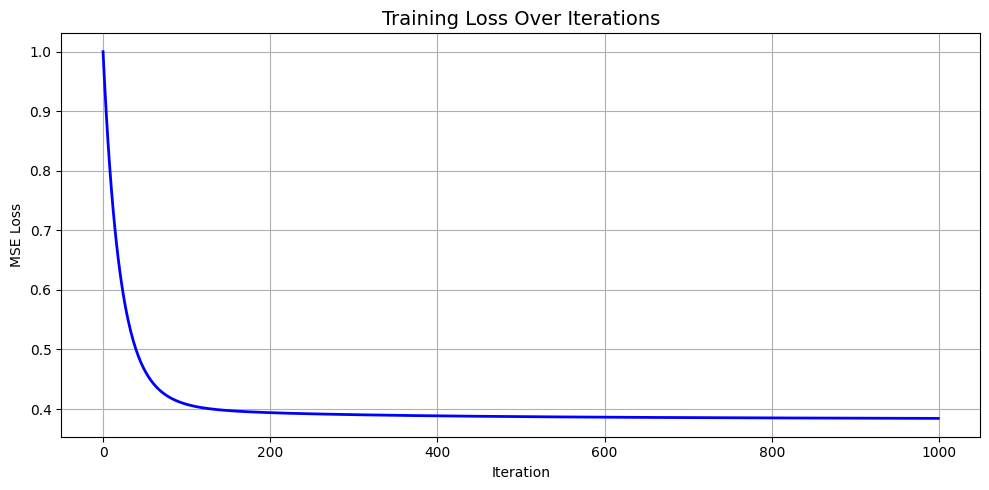

In [29]:
learning_rate = 0.01
n_iterations = 1000
n_features = X_train_scaled.shape[1]
w, b = initialize_weights(n_features)
loss_history = []
for i in range(n_iterations):
  y_pred = predict(X_train_scaled, w, b)
  loss = compute_loss(y_train_scaled, y_pred)
  loss_history.append(loss)
  dw, db = compute_gradients(X_train_scaled, y_train_scaled, y_pred)
  w, b = update_weights(w, b, dw, db, learning_rate)
  if (i % 100 == 0):
        print(f"Iteration {i:4d} | Loss: {loss:.6f}")
print(f"\nFinal training loss: {loss_history[-1]:.6f}")
#plot:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Training Loss Over Iterations', fontsize=14)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png',bbox_inches='tight')
plt.show()


## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
EVALUATION RESULTS ON TEST SET
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
MAE  : 7.2276 MPa
RMSE : 9.1862 MPa
R2   : 0.4471
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=


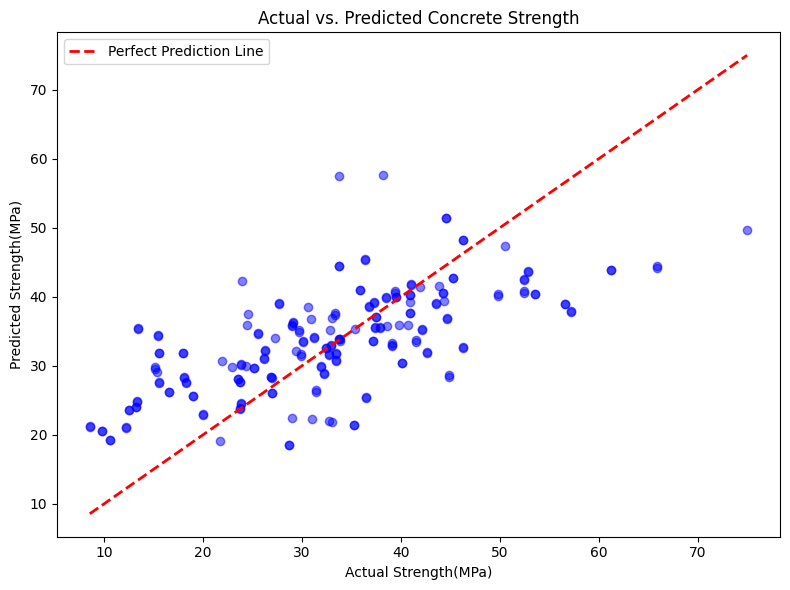

In [32]:
y_pred_scaled=predict(X_test_scaled,w,b)
y_pred_actual=(y_pred_scaled*y_std)+y_mean
y_test_actual=(y_test_scaled*y_std)+y_mean
n = len(y_test_actual)
errors=y_pred_actual-y_test_actual
#Mean Absolute Error
mae=np.mean(np.abs(errors))
#Root Mean Squared Error
rmse=np.sqrt(np.mean(errors**2))
#R-Squared Error
ss_res=np.sum(errors**2)
ss_tot=np.sum((y_test_actual-y_test_actual.mean())**2)
r2=1-(ss_res/ss_tot)
print("*="*25)
print("EVALUATION RESULTS ON TEST SET")
print("*="*25)
print(f"MAE  : {mae:.4f} MPa")
print(f"RMSE : {rmse:.4f} MPa")
print(f"R2   : {r2:.4f}")
print("*="*25)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual,y_pred_actual,alpha=0.5,color='blue')
plt.plot([y_test_actual.min(),y_test_actual.max()],[y_test_actual.min(),y_test_actual.max()],'r--',lw=2,label='Perfect Prediction Line')
plt.xlabel('Actual Strength(MPa)')
plt.ylabel('Predicted Strength(MPa)')
plt.title('Actual vs. Predicted Concrete Strength')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
 I implemented the entire linear regression pipeline using only NumPy:
- Standardization of features manually using mean and std
- Forward pass: predictions using matrix multiplication (X·w + b)
- Loss computation using Mean Squared Error formula
- Gradient computation using the derivative of MSE with respect to w and b
- Weight update rule: w = w - learning_rate * gradient

2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
  Initially the loss was high, and in the first 200 iterations ,loss decreased at a fast pace.later on,it flattened out as the weights reached optimal values.

  It is explained by the fact that gradient descent takes large steps early when the error is big, and smaller steps later as it approaches towards minimum.
3. What have you learned from implementing and evaluating this model from scratch in this notebook?
*Before this I had no idea how a machine learning model actually works
internally. Implementing it from scratch made it clear that gradient
descent is just repeatedly asking which direction makes things worse?
and moving the opposite way.